# Coffee-only saliency walkthrough

This notebook is a condensed version of the full salienct map implementation in saliency_map.ipynb,
In this example i'll be exclusively focussing on the Coffee dataset.

This notebook:
- Loads & fits `HydraModelExplainable`
- Generates saliency maps
- Runs masking based evaluation on Coffee
- Plots relative score drop and flip rate by masking fraction
- Fits `MrSQMExplainableModel` for comparison of saliency results
- Plots the highest variance vs highest discriminative feature region

## 1. Setup

In [1]:
import gc
import os
import sys
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import Patch

# Project imports
from experiments.utils import load_dataset
from experiments.utils.explainability import evaluate_masking_dataset
from experiments.init_models.hydra_explainable import HydraModelExplainable
from experiments.init_models.mrsqm_explainable import MrSQMExplainableModel

# Add project root to path
sys.path.insert(0, os.path.abspath("../.."))

# NOTE - Globals
OUTPUT_DIR = Path("outputs")
FIG_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

DATASET = "Coffee"
FRACTIONS = (0.05, 0.10, 0.20)
RANDOM_REPEATS = 3
SEED = 42

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

MODE_ORDER = ["top", "random", "bottom"]

MODE_LABELS = {
    "top": "Top-saliency masking",
    "random": "Random masking",
    "bottom": "Bottom-saliency masking",
}

MODE_COLORS = {
    "top": "#1f77b4",
    "random": "#7f7f7f",
    "bottom": "#d62728",
}


# Loading device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Dataset:", DATASET)
print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print("Figure dir:", FIG_DIR)

Dataset: Coffee
Device: cuda
Output dir: outputs
Figure dir: figures


---
### Load the Coffee dataset

Train shape: (28, 286)
Test shape : (28, 286)
Classes : [0 1]
Metadata : LabelEncoder()


/home/eoin/projects/ts_assignment/experiments/utils/data_utils.py:69: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  x_train, y_train = load_classification(name, split="train")
/home/eoin/projects/ts_assignment/experiments/utils/data_utils.py:70: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  x_test, y_test = load_classification(name, split="test")


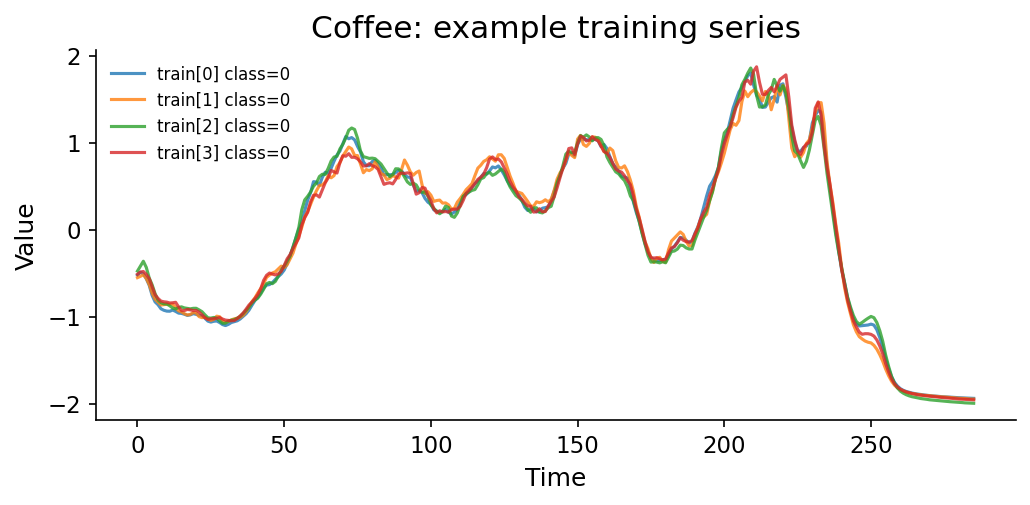

In [2]:
# Load dataset
x_train, y_train, x_test, y_test, metadata = load_dataset(DATASET)
print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)
print("Classes :", np.unique(y_train))
print("Metadata :", metadata)


# NOTE - Series example
fig, ax = plt.subplots(figsize=(7, 3.5))
for i in range(min(4, len(x_train))):
    series = np.asarray(x_train[i]).squeeze()
    ax.plot(series, alpha=0.8, label=f"train[{i}] class={y_train[i]}")
ax.set_title("Coffee: example training series")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

Helper functions for script

In [3]:
def style_axis(ax):
    ''' Add horizontal grid
    '''
    ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    ax.set_axisbelow(True)


def save_figure(fig, name: str):
    ''' generic save fig function for png and pdf
    '''
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")


def clean_saliency(saliency: np.ndarray):
    ''' remove NaN/inf & take ABS vals
    '''
    saliency = np.asarray(saliency, dtype=float).squeeze()
    saliency = np.nan_to_num(saliency, nan=0.0, posinf=0.0, neginf=0.0)
    return np.abs(saliency)


def normalize_0_100(values: np.ndarray):
    ''' Scale values to [0, 100] for visualisation
    '''
    values = clean_saliency(values)
    vmin = np.min(values)
    vmax = np.max(values)
    if np.isclose(vmin, vmax):
        return np.zeros_like(values)
    return 100.0 * (values - vmin) / (vmax - vmin)


def summarize_relative_metrics(samples_df: pd.DataFrame):
    '''  Main function for generating metrics
    '''
    df = samples_df.copy()

    # Compute relative score drop (% of original score)
    df["relative_score_drop_pct"] = (df["score_drop"] / df["score_before"].abs().replace(0, np.nan)) * 100.0
    # AGG metrics across samples
    summary = (
        df.groupby(["fraction", "mode"], as_index=False)
          .agg(
              mean_relative_score_drop_pct=("relative_score_drop_pct", "mean"),
              median_relative_score_drop_pct=("relative_score_drop_pct", "median"),
              flip_rate=("flipped", "mean"),
              flip_rate_pct=("flipped", lambda x: 100.0 * np.mean(x)),
              n_samples=("flipped", "size"),
          )
          .sort_values(["fraction", "mode"])
    )
    return summary


def choose_shared_correct_example(model_a, model_b, X_test, y_test):
    ''' Find first index correctly predicted by both models
    '''
    pred_a = model_a.predict(X_test)
    pred_b = model_b.predict(X_test)
    idxs = np.where((pred_a == y_test) & (pred_b == y_test))[0]
    return int(idxs[0]) if len(idxs) else 0


def plot_signal_with_saliency(series, saliency, title: str, save_name: str | None = None):
    ''' Main function for plotting a TS signal with saliency on top
    '''
    # clean & norm data
    x = np.arange(len(np.asarray(series).squeeze()))
    y = np.asarray(series).squeeze()
    s = normalize_0_100(saliency)

    # Figure formatting for colour bar
    fig = plt.figure(figsize=(8.2, 3.8), constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[30, 1])
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    # Scatter coloured by saliency + underlying line plot
    sc = ax.scatter(x, y, c=s, cmap="jet", s=22, linewidths=0, vmin=0, vmax=100)
    ax.plot(x, y, linewidth=1.1, alpha=0.35, color="black")

    # Formatting
    ax.set_title(title)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")
    style_axis(ax)
    # Colorbar
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("Normalised saliency")
    save_figure(fig, save_name)
    plt.show()


def plot_grouped_bars(df, value_col, title, ylabel, filename, show_percent_symbol=False):
    ''' Function taken from saliency_map.ipynb that plots grouped bars
    '''
    # Get masking fractions
    fractions = sorted(df["fraction"].unique())
    fig, ax = plt.subplots(figsize=(7.8, 4.8))

    # Bar positions and offsets for modes
    x = np.arange(len(fractions))
    width = 0.24
    offsets = [-width, 0, width]

    # NOTE - Plot grouped bars for each masking mode
    for offset, mode in zip(offsets, MODE_ORDER):
        sub = df[df["mode"] == mode].sort_values("fraction")
        y = sub[value_col].to_numpy()
        # Plot bars
        bars = ax.bar(x + offset, y, width=width, color=MODE_COLORS[mode], alpha=0.85, label=MODE_LABELS[mode])

        # Add value labels above bars
        for bar, val in zip(bars, y):
            label = f"{val:.1f}%" if show_percent_symbol else f"{val:.2f}"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=9)

    # Formatting
    ax.set_title(title)
    ax.set_xlabel("Masked fraction of time steps")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{f:.0%}" for f in fractions])
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    style_axis(ax)
    ax.legend(frameon=False, loc="best")

    # headroom for labels
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.15)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()

### Fit HydraModelExplainable on Coffee

In [4]:
hydra = HydraModelExplainable(input_dim=x_train.shape[-1], seed=SEED, device=DEVICE)
hydra.fit(x_train, y_train)

hydra_preds = hydra.predict(x_test)
hydra_acc = np.mean(hydra_preds == y_test)
print(f"HYDRA test accuracy on Coffee: {hydra_acc:.3f}")

[HydraModel] Using device: cuda
[HydraModel] Using latency optimisation
HYDRA test accuracy on Coffee: 1.000


### Run masking evaluation for HYDRA

In [6]:
# NOTE - Run masking evaluation
hydra_samples, hydra_summary_raw = evaluate_masking_dataset(
    model=hydra,
    X_test=x_test,
    y_test=y_test,
    fractions=FRACTIONS,
    use_absolute=True,
    only_correct=True,
    random_repeats=RANDOM_REPEATS,
    seed=SEED,
)

hydra_samples["dataset"] = DATASET
hydra_samples["model"] = "HYDRA"

# NOTE - Generate summary metrics
hydra_summary = summarize_relative_metrics(hydra_samples)
display(hydra_summary)

hydra_samples.to_csv(OUTPUT_DIR / "coffee_hydra_samples.csv", index=False)
hydra_summary.to_csv(OUTPUT_DIR / "coffee_hydra_summary.csv", index=False)
print("Saved HYDRA results")

  processed 10/28 samples
  processed 20/28 samples


,fraction,mode,mean_relative_score_drop_pct,median_relative_score_drop_pct,flip_rate,flip_rate_pct,n_samples
0,0.05,bottom,5.906485,9.852520,0.000000,0.000000,28
1,0.05,random,21.158623,11.203542,0.059524,5.952381,28
2,0.05,top,29.564920,31.433212,0.071429,7.142857,28
3,0.10,bottom,7.943062,20.098669,0.035714,3.571429,28
4,0.10,random,25.061984,25.097900,0.083333,8.333333,28
5,0.10,top,50.067764,87.184715,0.321429,32.142857,28
6,0.20,bottom,15.116744,35.844297,0.035714,3.571429,28
7,0.20,random,38.501817,51.775446,0.214286,21.428571,28
8,0.20,top,55.302736,32.516881,0.214286,21.428571,28


Saved HYDRA results


### Plot HYDRA masking results

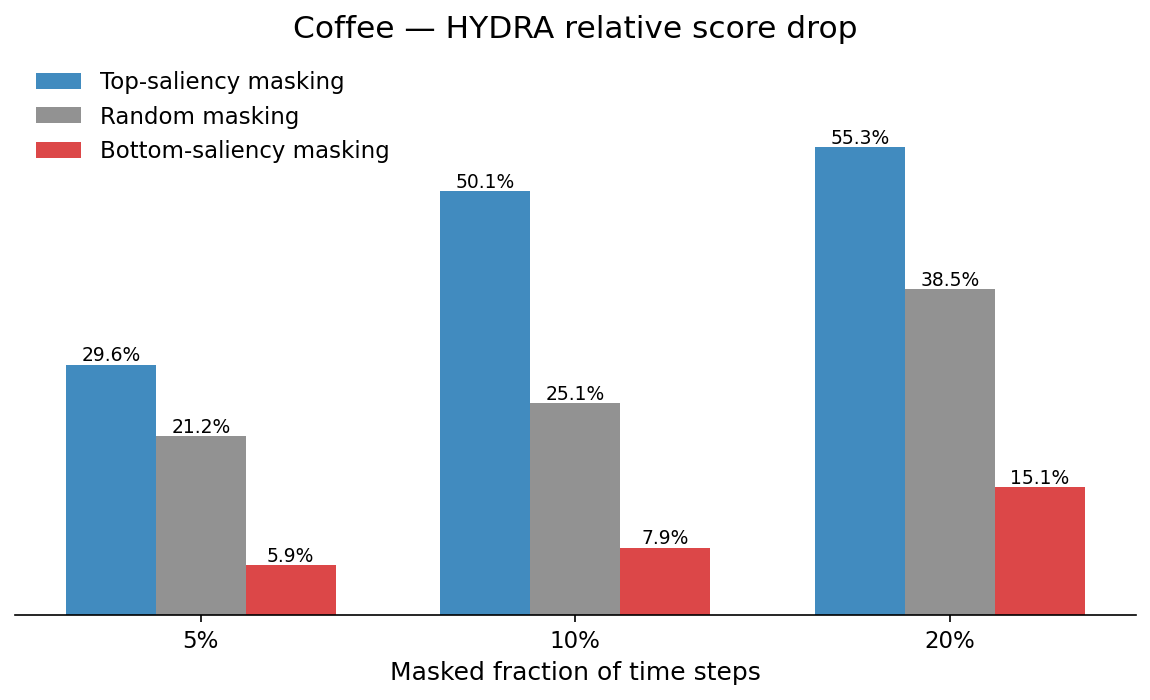

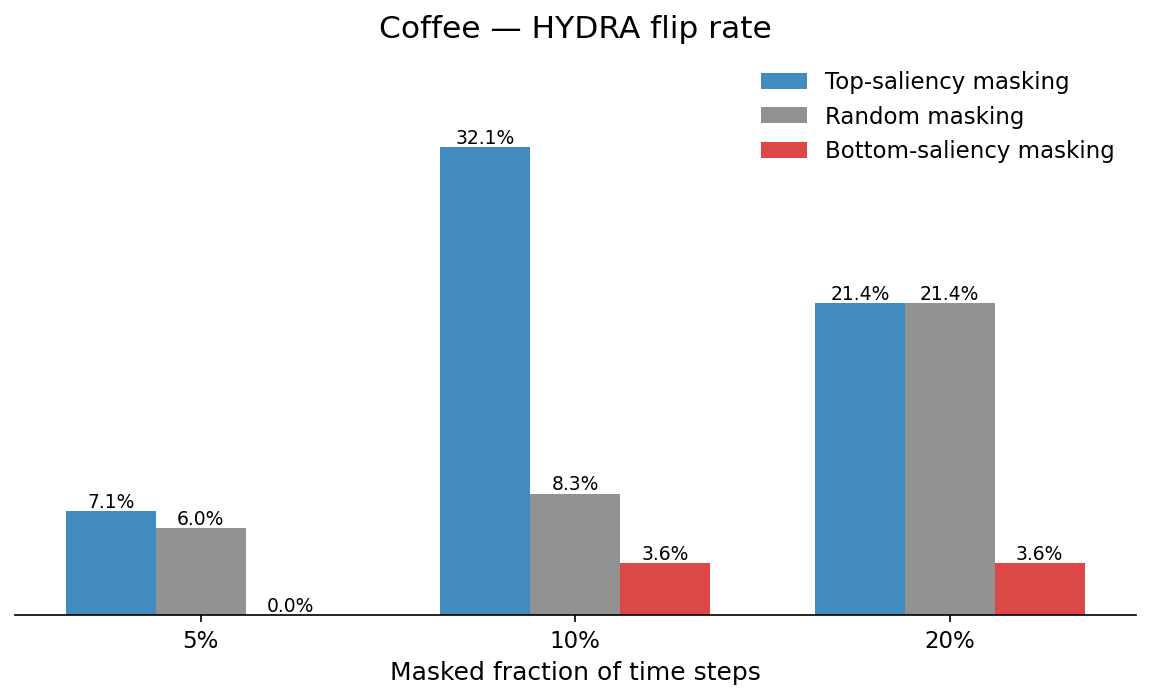

In [7]:
plot_grouped_bars(
    df=hydra_summary,
    value_col="mean_relative_score_drop_pct",
    title="Coffee — HYDRA relative score drop",
    ylabel="Mean relative score drop (%)",
    filename="hydra_mean_relative_score_drop_grouped_bars",
    show_percent_symbol=True,
)

plot_grouped_bars(
    df=hydra_summary,
    value_col="flip_rate_pct",
    title="Coffee — HYDRA flip rate",
    ylabel="Prediction flip rate (%)",
    filename="hydra_mean_flip_rate_grouped_bars",
    show_percent_symbol=True,
)

### Plot a HYDRA saliency example

Example index: 0
True label: 0, HYDRA prediction: 0


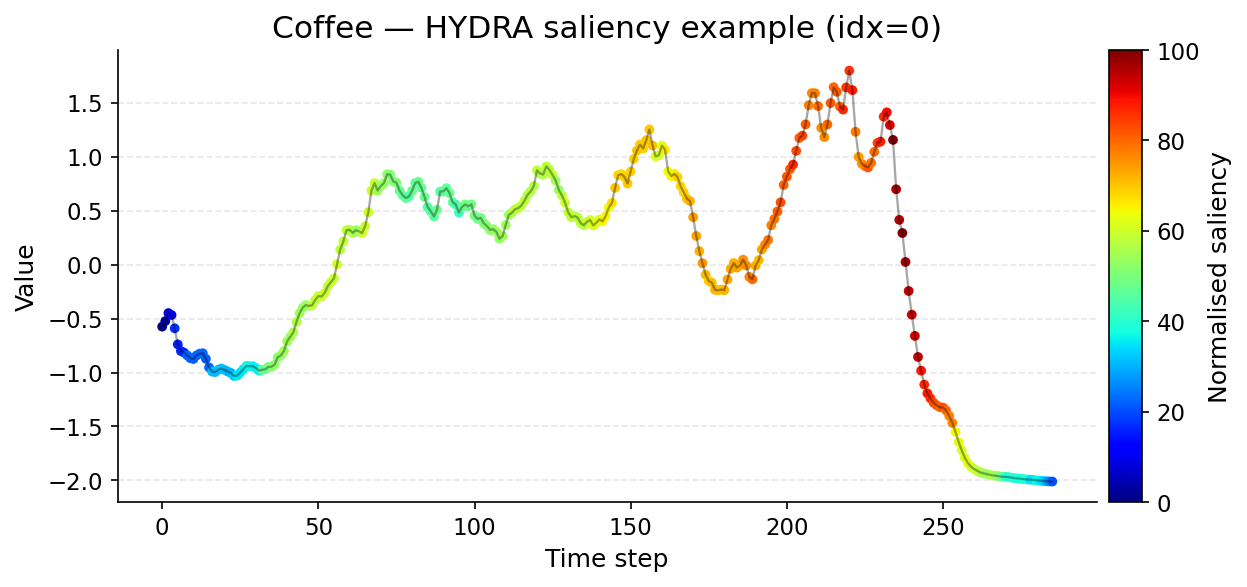

In [8]:
# Get samples with correct prediction as example
example_idx = int(np.where(hydra_preds == y_test)[0][0])

# Extract series and labels
example_series = x_test[example_idx]
example_label = y_test[example_idx]
example_pred = hydra_preds[example_idx]

# NOTE - Compute saliency
example_saliency = hydra.explain(example_series)
print(f"Example index: {example_idx}")
print(f"True label: {example_label}, HYDRA prediction: {example_pred}")

# NOTE - Plot time series with saliency overlay
plot_signal_with_saliency(
    example_series,
    example_saliency,
    title=f"Coffee — HYDRA saliency example (idx={example_idx})",
    save_name="coffee_hydra_saliency_example.png",
)

## MrSQMExplainableModel

We can now compare the saliency plot generated by HYDRA to MrSQM

In [9]:
mrsqm = MrSQMExplainableModel(nsax=5, nsfa=1)
mrsqm.fit(x_train, y_train)

mrsqm_preds = mrsqm.predict(x_test)
mrsqm_acc = np.mean(mrsqm_preds == y_test)
print(f"MrSQM test accuracy on Coffee: {mrsqm_acc:.3f}")

# NOTE - Perform same masking eval
mrsqm_samples, _ = evaluate_masking_dataset(
    model=mrsqm,
    X_test=x_test,
    y_test=y_test,
    fractions=FRACTIONS,
    use_absolute=True,
    only_correct=True,
    random_repeats=RANDOM_REPEATS,
    seed=SEED,
)

mrsqm_samples["dataset"] = DATASET
mrsqm_samples["model"] = "MrSQM"

mrsqm_summary = summarize_relative_metrics(mrsqm_samples)
display(mrsqm_summary)

mrsqm_samples.to_csv(OUTPUT_DIR / "coffee_mrsqm_samples.csv", index=False)
mrsqm_summary.to_csv(OUTPUT_DIR / "coffee_mrsqm_summary.csv", index=False)

2026-04-13 19:37:21,765 [INFO] Initialize MrSQM Classifier.
2026-04-13 19:37:21,767 [INFO] Feature Selection Strategy: RS
2026-04-13 19:37:21,767 [INFO] SAX Reps: 5x
2026-04-13 19:37:21,768 [INFO] SFA Reps: 1x
2026-04-13 19:37:21,768 [INFO] Number of features per rep: 500
2026-04-13 19:37:21,769 [INFO] Number of candidates per rep (only for SR and RS):2000
2026-04-13 19:37:22,891 [INFO] Fit logistic regression model.
/home/eoin/envs/ts_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1262: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


MrSQM test accuracy on Coffee: 0.964
  processed 10/27 samples
  processed 20/27 samples


,fraction,mode,mean_relative_score_drop_pct,median_relative_score_drop_pct,flip_rate,flip_rate_pct,n_samples
0,0.05,bottom,3.392931,3.049798,0.000000,0.000000,27
1,0.05,random,31.607868,27.895107,0.037037,3.703704,27
2,0.05,top,56.637211,44.643175,0.074074,7.407407,27
3,0.10,bottom,6.640457,7.689366,0.000000,0.000000,27
4,0.10,random,39.024645,39.394961,0.000000,0.000000,27
5,0.10,top,64.062195,60.043075,0.074074,7.407407,27
6,0.20,bottom,7.429394,8.467954,0.000000,0.000000,27
7,0.20,random,51.220468,53.915867,0.012346,1.234568,27
8,0.20,top,73.991359,74.699279,0.074074,7.407407,27


In [10]:
# Combine results
summary_list = [hydra_summary.assign(model="HYDRA")]
summary_list.append(mrsqm_summary.assign(model="MrSQM"))
combined_summary = pd.concat(summary_list, ignore_index=True)

# Filter to 10% masking for comparison
summary_10 = combined_summary[combined_summary["fraction"] == 0.10].copy()
summary_10 = summary_10.sort_values(["model", "mode"])

# Display
print("Results at 10% masking")
display(summary_10)


# NOTE - Plot relative score drop
score_drop_df = (
    summary_10
    .pivot(index="model", columns="mode", values="mean_relative_score_drop_pct")
    .reindex(columns=["top", "random", "bottom"])
    .round(3)
)
print("Mean score drop at 10% masking")
display(score_drop_df)


# NOTE - Plot flip rate
flip_df = (
    summary_10
    .pivot(index="model", columns="mode", values="flip_rate")
    .reindex(columns=["top", "random", "bottom"])
    .round(3)
)
print("Flip rate at 10% masking")
display(flip_df)

Results at 10% masking


,fraction,mode,mean_relative_score_drop_pct,median_relative_score_drop_pct,flip_rate,flip_rate_pct,n_samples,model
3,0.1,bottom,7.943062,20.098669,0.035714,3.571429,28,HYDRA
4,0.1,random,25.061984,25.097900,0.083333,8.333333,28,HYDRA
5,0.1,top,50.067764,87.184715,0.321429,32.142857,28,HYDRA
12,0.1,bottom,6.640457,7.689366,0.000000,0.000000,27,MrSQM
13,0.1,random,39.024645,39.394961,0.000000,0.000000,27,MrSQM
14,0.1,top,64.062195,60.043075,0.074074,7.407407,27,MrSQM


Mean score drop at 10% masking


mode,top,random,bottom
model,,,
HYDRA,50.068,25.062,7.943
MrSQM,64.062,39.025,6.640


Flip rate at 10% masking


mode,top,random,bottom
model,,,
HYDRA,0.321,0.083,0.036
MrSQM,0.074,0.000,0.000


## Compare HYDRA & MrSQM masking curves

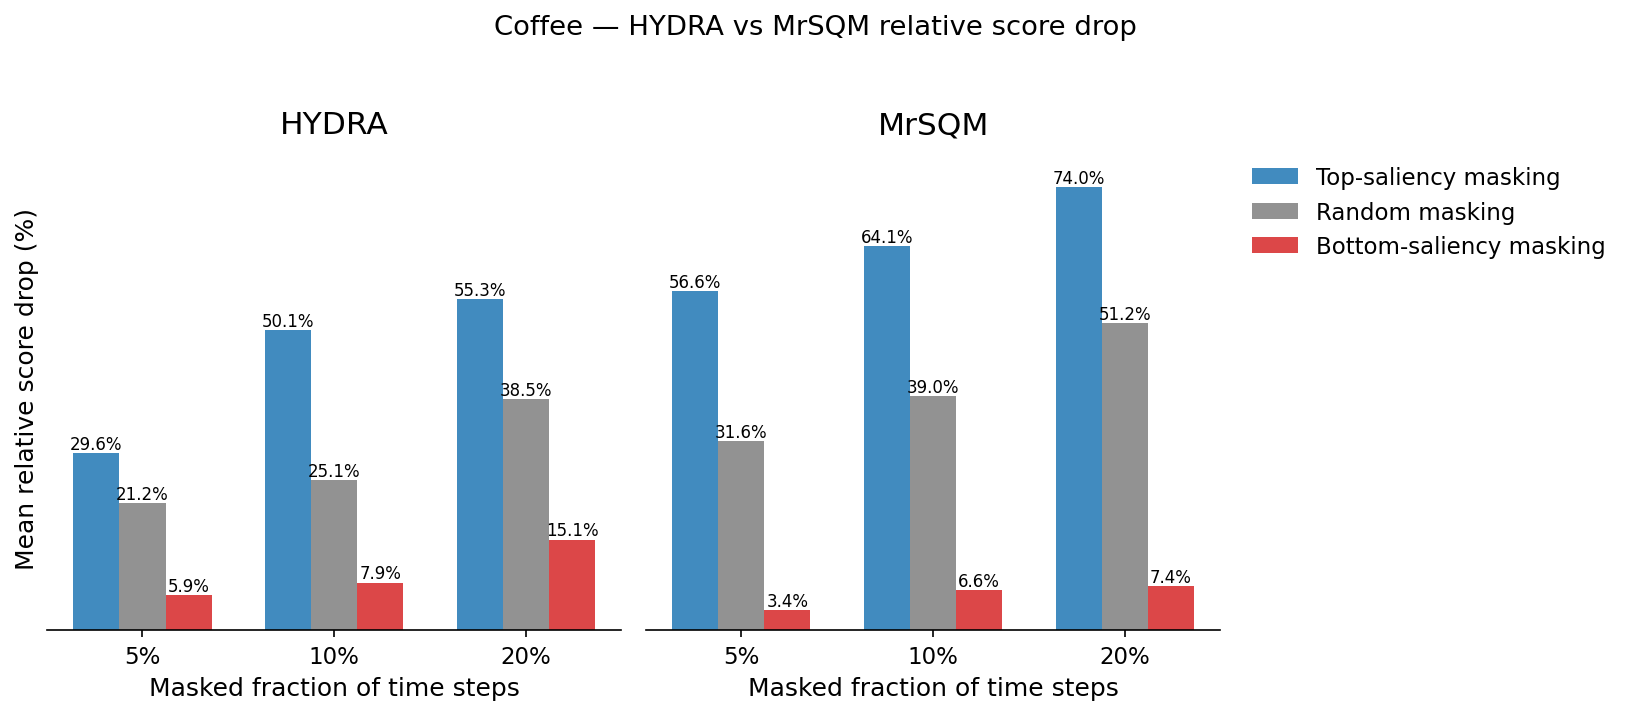

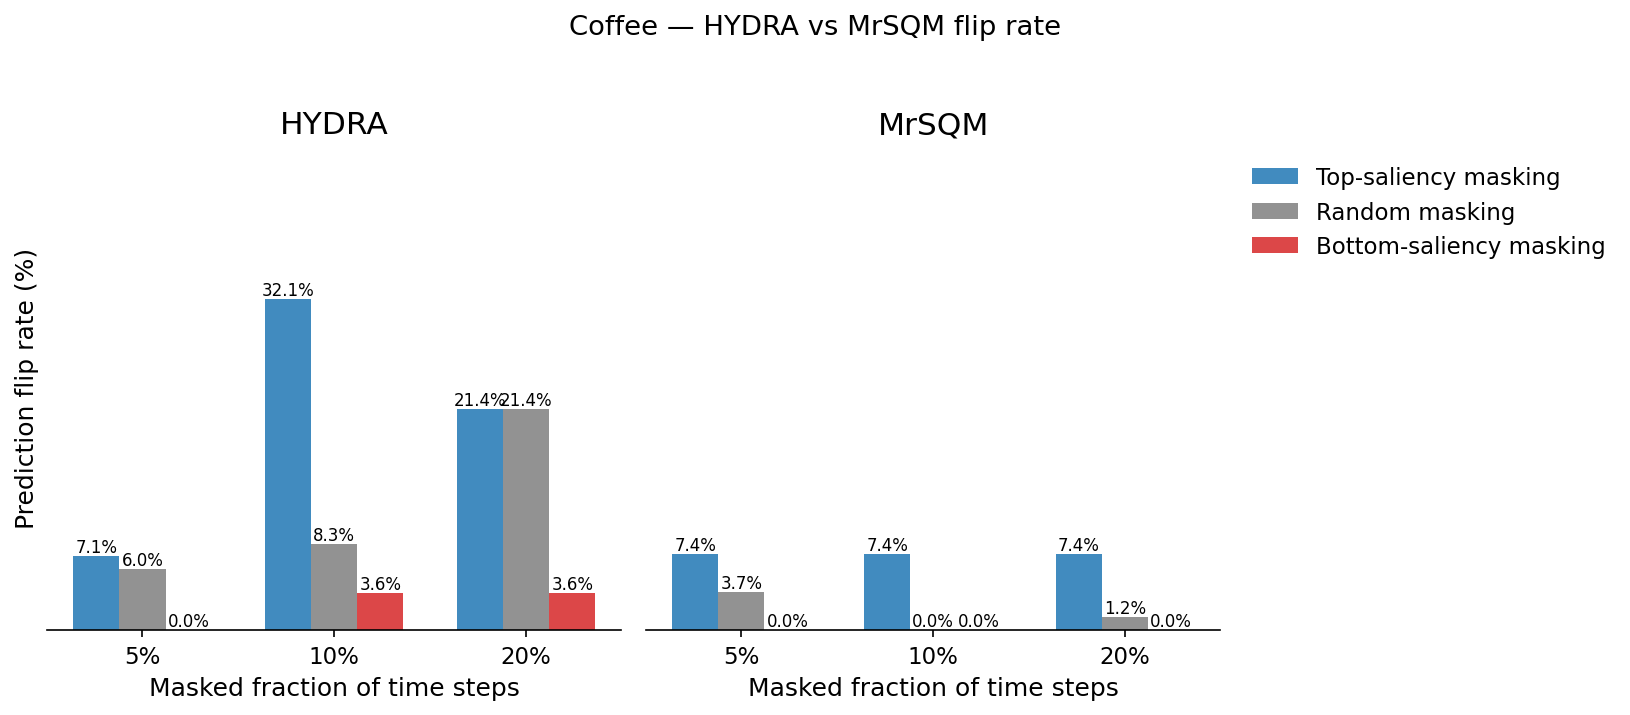

In [11]:
# Combine model summaries into DF
comparison = pd.concat([hydra_summary.assign(model="HYDRA"), mrsqm_summary.assign(model="MrSQM")], ignore_index=True)

def plot_grouped_bars_by_model(df, value_col, ylabel, title, filename, show_percent_symbol=False):
    ''' Mian functionf or generating bar plots comparing the masking effect on HYDRA vs MrSQM
    '''
    # Define models and masking fractions
    models = ["HYDRA", "MrSQM"]
    fractions = sorted(df["fraction"].unique())
    # Create one subplot per model
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
    x = np.arange(len(fractions))
    width = 0.24
    offsets = [-width, 0, width]

    for ax, model_name in zip(axes, models):
        model_df = df[df["model"] == model_name]
        # Plot grouped bars for each masking mode
        for offset, mode in zip(offsets, MODE_ORDER):
            sub = model_df[model_df["mode"] == mode].sort_values("fraction")
            y = sub[value_col].to_numpy()
            # NOTE - Create bars & add vals on top
            bars = ax.bar(x + offset, y, width=width, color=MODE_COLORS[mode], alpha=0.85, label=MODE_LABELS[mode])
            for bar, val in zip(bars, y):
                label = f"{val:.1f}%" if show_percent_symbol else f"{val:.2f}"
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=8)

        # Figure formatting
        ax.set_title(model_name)
        ax.set_xlabel("Masked fraction of time steps")
        ax.set_xticks(x)
        ax.set_xticklabels([f"{f:.0%}" for f in fractions])
        ax.set_ylabel("")
        ax.set_yticks([])
        ax.spines["left"].set_visible(False)
        style_axis(ax)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.18)

    # Shared y-label and legend
    axes[0].set_ylabel(ylabel)
    axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


# NOTE - Plot relative score drop comparison
plot_grouped_bars_by_model(
    df=comparison,
    value_col="mean_relative_score_drop_pct",
    ylabel="Mean relative score drop (%)",
    title="Coffee — HYDRA vs MrSQM relative score drop",
    filename="coffee_hydra_vs_mrsqm_relative_score_drop",
    show_percent_symbol=True,
)

# NOTE - Plot flip rate comparison
plot_grouped_bars_by_model(
    df=comparison,
    value_col="flip_rate_pct",
    ylabel="Prediction flip rate (%)",
    title="Coffee — HYDRA vs MrSQM flip rate",
    filename="coffee_hydra_vs_mrsqm_flip_rate",
    show_percent_symbol=True,
)

In [12]:
def plot_grouped_bars_combined(df, value_col, ylabel, title, filename, show_percent_symbol=False):
    ''' Function for plotting simialkr to above but with HYDRA & MrSQM cols adjacent for easier comparison
    '''
    models = ["HYDRA", "MrSQM"]

    # X-axis pos based on masking fractions
    fractions = sorted(df["fraction"].unique())
    x = np.arange(len(fractions))

    # Define offsets for the 6 bars
    width = 0.12
    offsets = {
        ("HYDRA", "top"): -2.5 * width,
        ("MrSQM", "top"): -1.5 * width,
        ("HYDRA", "random"): -0.5 * width,
        ("MrSQM", "random"): 0.5 * width,
        ("HYDRA", "bottom"): 1.5 * width,
        ("MrSQM", "bottom"): 2.5 * width,
    }

    # Plot bars for each (model, mode) combination
    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    for model in models:
        for mode in MODE_ORDER:
            sub = (df[(df["model"] == model) & (df["mode"] == mode)].sort_values("fraction"))
            y = sub[value_col].to_numpy()

            # NOTE - Generating bars based on model type
            bars = ax.bar(
                x + offsets[(model, mode)],
                y,
                width=width,
                color=MODE_COLORS[mode],
                alpha=0.9 if model == "HYDRA" else 0.55,  
                hatch=None if model == "HYDRA" else "//",
                edgecolor="black" if model == "MrSQM" else None,
                linewidth=0.6 if model == "MrSQM" else 0,
            )

            # NOTE - Add vals to bars
            for bar, val in zip(bars, y):
                label = f"{val:.1f}%" if show_percent_symbol else f"{val:.2f}"
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=6)

    # Axis formatting
    ax.set_title(title)
    ax.set_xlabel("Masked fraction of time steps")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{f:.0%}" for f in fractions])

    style_axis(ax)
    legend_handles = [
        Patch(facecolor=MODE_COLORS["top"], label="Top-saliency masking"),
        Patch(facecolor=MODE_COLORS["random"], label="Random masking"),
        Patch(facecolor=MODE_COLORS["bottom"], label="Bottom-saliency masking"),
        Patch(facecolor="black", alpha=0.9, label="HYDRA"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="MrSQM"),
    ]
    ax.legend(handles=legend_handles, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.18)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()

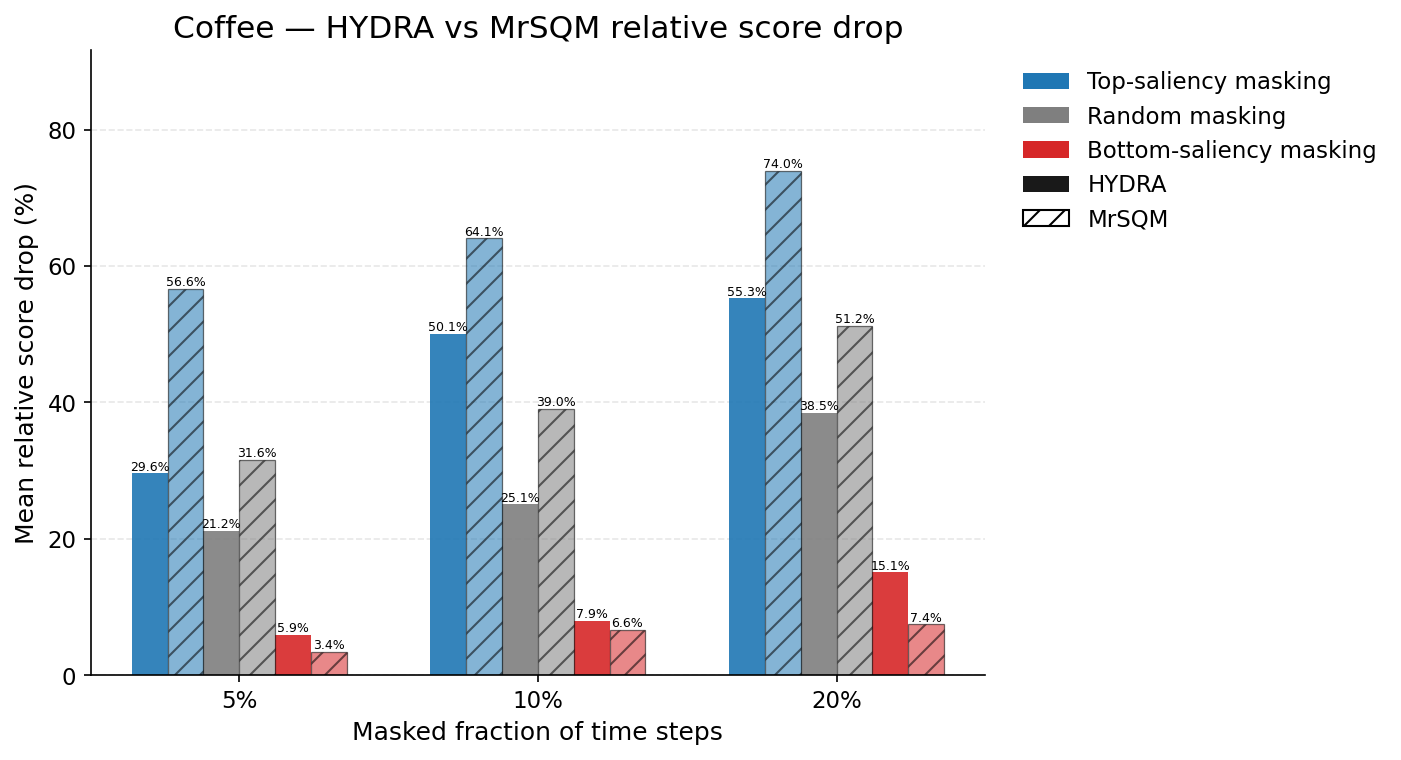

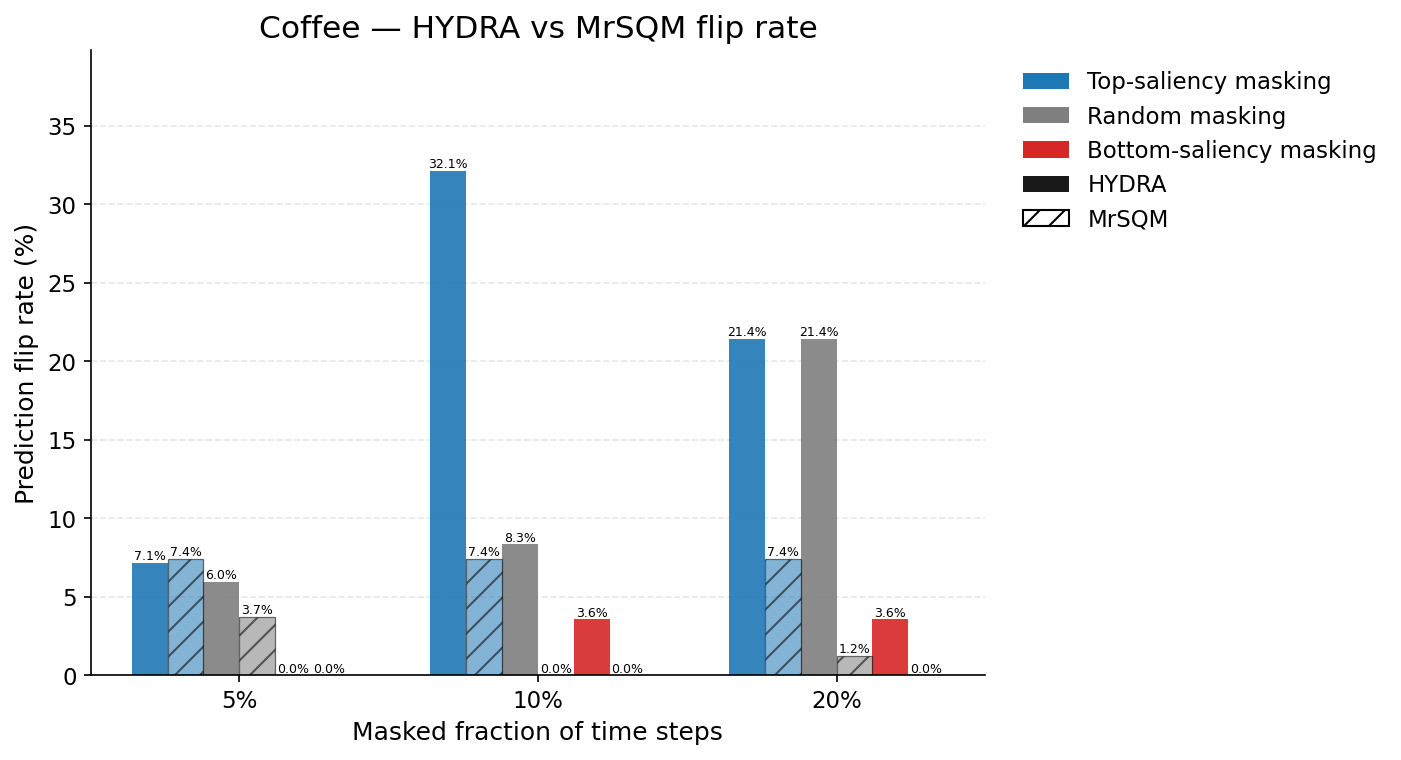

In [ ]:
# NOTE - Plot relative score drop comparison
plot_grouped_bars_combined(
    df=comparison,
    value_col="mean_relative_score_drop_pct",
    ylabel="Mean relative score drop (%)",
    title="Coffee — HYDRA vs MrSQM relative score drop",
    filename="coffee_hydra_vs_mrsqm_relative_score_drop_combined",
    show_percent_symbol=True,
)

# NOTE - Plot flip rate comparison
plot_grouped_bars_combined(
    df=comparison,
    value_col="flip_rate_pct",
    ylabel="Prediction flip rate (%)",
    title="Coffee — HYDRA vs MrSQM flip rate",
    filename="coffee_hydra_vs_mrsqm_flip_rate_combined",
    show_percent_symbol=True,
)

## Compare HYDRA and MrSQM saliency on the same Coffee series

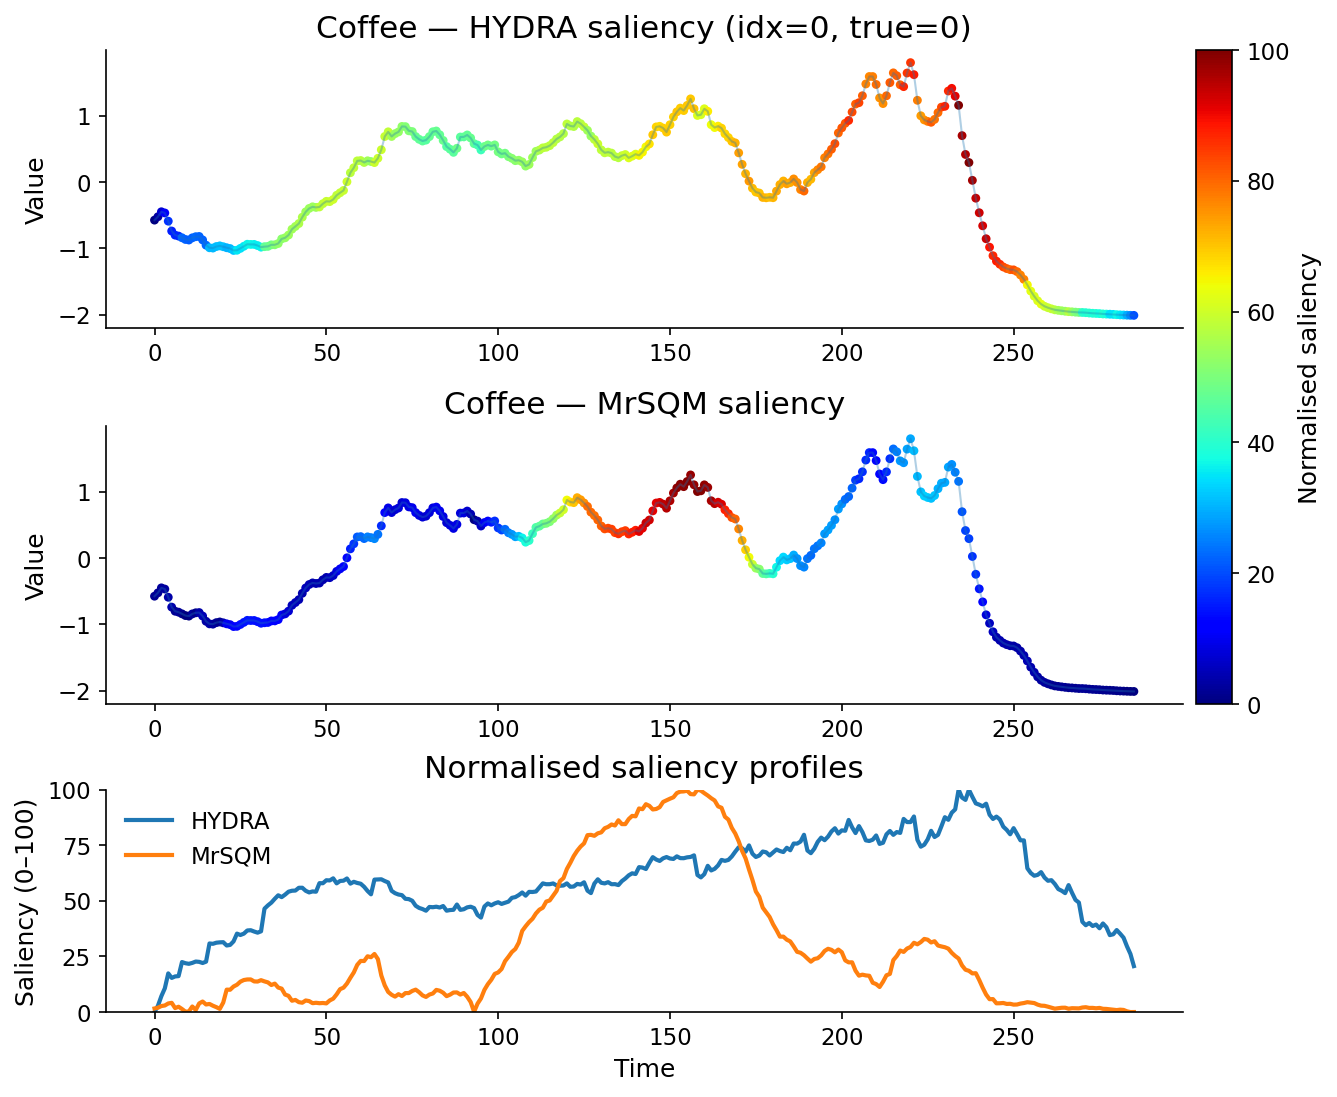

In [14]:
# Get sample correctly predicted by both models
shared_idx = choose_shared_correct_example(hydra, mrsqm, x_test, y_test)
shared_series = x_test[shared_idx]
shared_true = y_test[shared_idx]

# NOTE - Compute saliency for both models
hydra_sal = hydra.explain(shared_series)
mrsqm_sal = mrsqm.explain(shared_series)

# NOTE - Clean data
x = np.arange(len(np.asarray(shared_series).squeeze()))
y = np.asarray(shared_series).squeeze()
hydra_norm = normalize_0_100(hydra_sal)
mrsqm_norm = normalize_0_100(mrsqm_sal)

# Create figure layout with space for colorbar
fig = plt.figure(figsize=(8.8, 7.2), constrained_layout=True)
gs = fig.add_gridspec(3, 2, width_ratios=[30, 1], height_ratios=[1, 1, 0.8])

# Subplots: two saliency views + one comparison plot
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
cax = fig.add_subplot(gs[0:2, 1])  # colorbar for top panels

# NOTE - HYDRA saliency overlay
sc1 = ax1.scatter(x, y, c=hydra_norm, cmap="jet", s=18, linewidths=0, vmin=0, vmax=100)
ax1.plot(x, y, alpha=0.35, linewidth=1)
ax1.set_title(f"Coffee — HYDRA saliency (idx={shared_idx}, true={shared_true})")
ax1.set_ylabel("Value")

# NOTE - MrSQM saliency overlay
sc2 = ax2.scatter(x, y, c=mrsqm_norm, cmap="jet", s=18, linewidths=0, vmin=0, vmax=100)
ax2.plot(x, y, alpha=0.35, linewidth=1)
ax2.set_title("Coffee — MrSQM saliency")
ax2.set_ylabel("Value")

# Colourbar
cbar = fig.colorbar(sc2, cax=cax)
cbar.set_label("Normalised saliency")

# Plotting
ax3.plot(x, hydra_norm, linewidth=2, label="HYDRA")
ax3.plot(x, mrsqm_norm, linewidth=2, label="MrSQM")
ax3.set_title("Normalised saliency profiles")
ax3.set_xlabel("Time")
ax3.set_ylabel("Saliency (0–100)")
ax3.set_ylim(0, 100)
ax3.legend(frameon=False)

# Formatting
for ax in [ax1, ax2, ax3]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Save and display figure
fig.savefig(FIG_DIR / "coffee_hydra_vs_mrsqm_saliency.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
def select_plot_subset(X, y, n_per_class=5):
    ''' Cleaning up graph and only selecting <<n_per_class>> samples to visualise
    '''
    selected_idx = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        take = min(n_per_class, len(cls_idx))
        selected_idx.extend(cls_idx[:take])
    selected_idx = np.array(selected_idx)
    return X[selected_idx], y[selected_idx]


def load_dataset_for_plotting(dataset_name, channel=0):
    '''Load train/test splits  merge & return a 2D array for plotting
    '''
    x_train, y_train, x_test, y_test, _ = load_dataset(dataset_name)

    # Combine train and test for full-dataset scoring
    X = np.concatenate([x_train, x_test], axis=0)
    y = np.concatenate([y_train, y_test], axis=0)

    # Handle univariate vs multivariate input
    if X.ndim == 3:
        X_plot = X[:, channel, :]
    elif X.ndim == 2:
        X_plot = X
    else:
        raise ValueError(f"Unexpected X shape for {dataset_name}: {X.shape}")
    return X_plot, y


def compute_window_scores(X_sel, y_sel, window_frac=0.18, min_window=5):
    ''' Compute sliding window scores for:
        * variation: overall local variability
        * separation: between-class difference relative to within-class spread
    '''
    series_length = X_sel.shape[1]
    window = max(min_window, int(series_length * window_frac))
    classes = np.unique(y_sel)

    variation_scores = []
    separation_scores = []

    # Sliding window across TS
    for start in range(series_length - window + 1):
        end = start + window
        segment = X_sel[:, start:end]
        # NOTE - Variation score = AVG std across all series in window
        variation = np.mean(np.std(segment, axis=0))
        variation_scores.append(variation)

        # NOTE - Separation score = between class spread / in class spread
        class_means = []
        class_vars = []

        for cls in classes:
            cls_seg = segment[y_sel == cls]
            if len(cls_seg) == 0:
                continue
            class_means.append(np.mean(cls_seg, axis=0))
            class_vars.append(np.mean(np.var(cls_seg, axis=0)))

        if len(class_means) >= 2:
            class_means = np.array(class_means)
            between = np.mean(np.var(class_means, axis=0))
            within = np.mean(class_vars) + 1e-8
            separation = between / within
        else:
            separation = 0.0

        separation_scores.append(separation)

    variation_scores = np.array(variation_scores)
    separation_scores = np.array(separation_scores)

    # Best windows for each score
    var_start = int(np.argmax(variation_scores))
    sep_start = int(np.argmax(separation_scores))
    return {
        "series_length": series_length,
        "window": window,
        "variation_scores": variation_scores,
        "separation_scores": separation_scores,
        "var_start": var_start,
        "var_end": var_start + window,
        "sep_start": sep_start,
        "sep_end": sep_start + window,
    }


def plot_variation_vs_discrimination(dataset_name, X_sel, y_sel, score_info, save_path=None, show=True, figsize=(10, 5)):
    '''Plot series and highlight the highest variation & most discriminative windows
    '''
    x_axis = np.arange(score_info["series_length"])
    fig, ax = plt.subplots(figsize=figsize)

    # Plot selected series
    classes = np.unique(y_sel)
    for cls in classes:
        cls_series = X_sel[y_sel == cls]
        for series in cls_series:
            ax.plot(x_axis, series, linewidth=1.0, alpha=0.65)

    # NOTE - Window with largest variation
    ax.axvspan(score_info["var_start"], score_info["var_end"], alpha=0.18, color="red", label="Highest variance",)

    # NOTE - window with strongest class separation
    ax.axvspan(score_info["sep_start"], score_info["sep_end"], alpha=0.18, color="green", label="Discriminative feature region",)

    # Formatting
    ax.set_title(f"{dataset_name}: Variation vs discrimination", fontsize=12)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    plt.tight_layout()

    # Save
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax


def generate_dataset_figure(dataset_name, n_per_class=2, window_frac=0.18, channel=0, save_dir=None, show=True):
    '''Main function for building variation vs discrimination figure
    '''
    # NOTE - Using full dataset to compute window scores
    X_all, y_all = load_dataset_for_plotting(dataset_name=dataset_name, channel=channel,)

    score_info = compute_window_scores(X_sel=X_all, y_sel=y_all, window_frac=window_frac,)

    # NOTE - Get smaller sibset for plotting
    X_plot, y_plot = select_plot_subset(X_all, y_all, n_per_class=n_per_class)

    save_path = None
    if save_dir is not None:
        save_path = Path(save_dir) / f"{dataset_name}_variation_vs_discrimination.png"

    # NOTE - PLot Fig
    fig, ax = plot_variation_vs_discrimination(
        dataset_name=dataset_name,
        X_sel=X_plot,
        y_sel=y_plot,
        score_info=score_info,
        save_path=save_path,
        show=show,
    )

    return {
        "dataset": dataset_name,
        "window": score_info["window"],
        "var_start": score_info["var_start"],
        "var_end": score_info["var_end"],
        "sep_start": score_info["sep_start"],
        "sep_end": score_info["sep_end"],
    }

/home/eoin/projects/ts_assignment/experiments/utils/data_utils.py:69: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  x_train, y_train = load_classification(name, split="train")
/home/eoin/projects/ts_assignment/experiments/utils/data_utils.py:70: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  x_test, y_test = load_classification(name, split="test")


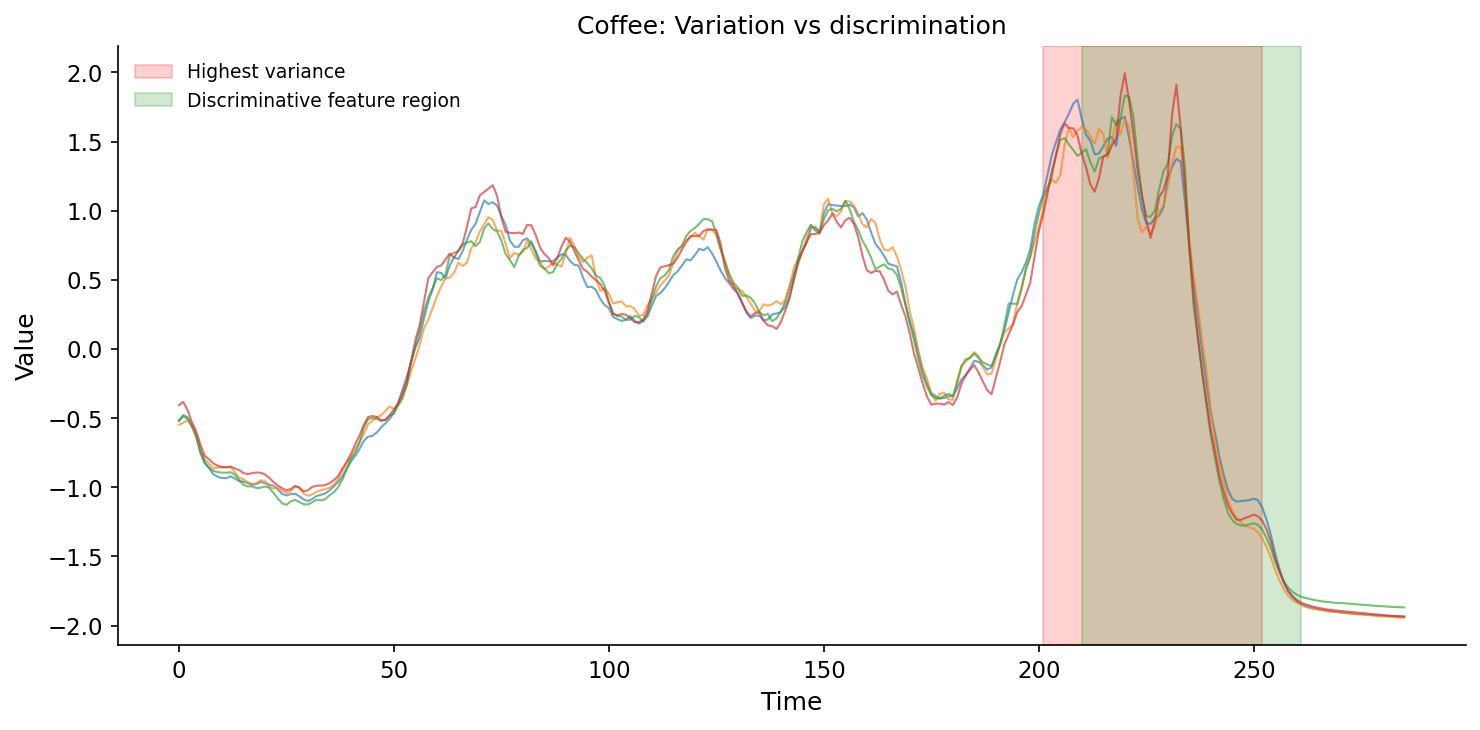

In [16]:
dataset_name = "Coffee"

X_all, y_all = load_dataset_for_plotting(dataset_name)
score_info = compute_window_scores(X_all, y_all, window_frac=0.18)
X_plot, y_plot = select_plot_subset(X_all, y_all, n_per_class=2)

fig, ax = plot_variation_vs_discrimination(
    dataset_name=dataset_name,
    X_sel=X_plot,
    y_sel=y_plot,
    score_info=score_info,
    save_path=FIG_DIR / "coffee_variation_vs_discrimination.png",
    show=True,
)

## 11. Clean up

In [ ]:
# Optional cleanup for long-running notebook sessions
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("Done.")